# PD Analysis (Modular)

This notebook is a concise entry point. All heavy lifting lives in `pd_pipeline/`.


In [17]:
import pandas as pd

from pd_pipeline import basel, capital, config, data, lasso, plots, portfolio, scenario, sensitivity


In [18]:
# Load and merge macro + GPR data
macro_frames = data.load_macro_data(
    gdp_path='data/macro/sweden_gdp_monthly.csv',
    interest_path='data/macro/sweden_interest_rate_monthly.csv',
    unemployment_path='data/macro/sweden_unemployment_monthly.csv',
    housing_path='data/macro/Bostadspriser ScB 1997-2025_transposed.csv',
    cpi_path='data/macro/KPI SCB 1980-2026.csv',
    verbose=True,
)

df_gpr = data.load_gpr_data('data/geopolitical/data_gpr_Data_GPR.csv', verbose=True)

df_merged = data.merge_macro_data(macro_frames, df_gpr)

cov_matrix, corr_matrix, mean_vector = data.summarize_macro_data(
    df_merged,
    config.ALL_PREDICTOR_COLS,
    verbose=True,
)


Cleaned df_gdp head:
        Date  GDP_Growth
1 2000-02-01         1.8
2 2000-03-01         0.5
3 2000-04-01         0.0
4 2000-05-01         2.8
5 2000-06-01         0.5

Cleaned df_interest head:
        Date  Interest_Rate
0 1990-01-01           11.4
1 1990-02-01           13.0
2 1990-03-01           13.5
3 1990-04-01           12.9
4 1990-05-01           12.0

Cleaned df_unemployment head:
        Date  Unemployment_Rate
0 1983-01-01                3.4
1 1983-02-01                3.7
2 1983-03-01                3.7
3 1983-04-01                3.4
4 1983-05-01                3.7

Cleaned df_housing head:
        Date  Housing_Prices
0 1997-01-01             749
1 1997-02-01             711
2 1997-03-01             746
3 1997-04-01             737
4 1997-05-01             738

Cleaned df_cpi head:
        Date    CPI
0 1980-01-01  28.38
1 1980-02-01  28.81
2 1980-03-01  28.96
3 1980-04-01  29.15
4 1980-05-01  29.25

Cleaned df_gpr head:
        Date  GPR_Global  GPR_Sweden
0 1985-01-

In [19]:
# Load PDs and merge with macro data

# Note: filesystem is case-insensitive on macOS, so data/PDs and data/pds both work

df_pds = data.load_pds_data('data/PDs/pdsFitchData.csv', verbose=True)

df_final = data.merge_pds_macro(df_pds, df_merged, verbose=True)

df_final_cleaned = data.prepare_model_data(
    df_final,
    config.ALL_PREDICTOR_COLS,
    sector_col=config.SECTOR_COL,
    verbose=True,
)


Columns in df_pds: ['Company_number', 'Date', '12_month', 'Sector', 'PDzero']

First few rows of df_pds:
       Company_number       Date  12_month                      Sector  PDzero
40854      80091583.0 2012-07-01    0.0012  Transportation & Logistics  0.0012
40855      80091583.0 2015-04-01    0.0012  Transportation & Logistics  0.0012
23177      80091774.0 2012-07-01    0.0012          Energy & Resources  0.0012
23178      80091774.0 2012-07-01    0.0012          Energy & Resources  0.0012
23179      80091774.0 2012-07-01    0.0005          Energy & Resources  0.0012

Before merge - PD data shape: (84585, 5)
Before merge - Macro data shape: (553, 8)
Non-null Sector values: 72119 (85.3%)

After merge - Final data shape: (84585, 12)
Retained 84585 out of 84585 PD datapoints (100.0%)

First few rows of the merged DataFrame (df_final):
   Company_number       Date  12_month                      Sector  PDzero  \
0      80091583.0 2012-07-01    0.0012  Transportation & Logistics  0.001

In [20]:
# Export cleaned dataset for reuse
data.export_dataframe(df_final_cleaned, output_file='df_final_cleaned.csv', verbose=True)


✓ Successfully exported dataframe to: df_final_cleaned.csv
  - Rows: 72,119
  - Columns: 12
  - File size: 11.47 MB (approximate)


In [21]:
# OLS sensitivity analysis

df_sensitivities = sensitivity.run_sensitivity_analysis(
    df_final_cleaned,
    macro_cols=config.MACRO_COLS,
    gpr_cols=config.GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    verbose=True,
)

print("\n" + "="*80)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*80)
print(df_sensitivities)



Processing sector: Transportation & Logistics (n=2934)
  ✓ 12_month: R²=0.033, N=2934

Processing sector: Energy & Resources (n=20212)
  ✓ 12_month: R²=0.048, N=20212

Processing sector: Telecommunications & Media (n=7152)
  ✓ 12_month: R²=0.077, N=7152

Processing sector: Financial Services (n=11109)
  ✓ 12_month: R²=0.025, N=11109

Processing sector: Industrial & Manufacturing (n=9534)
  ✓ 12_month: R²=0.053, N=9534

Processing sector: Consumer Goods & Retail (n=8061)
  ✓ 12_month: R²=0.025, N=8061

Processing sector: Professional Services & Consulting (n=1199)
  ✓ 12_month: R²=0.035, N=1199

Processing sector: Technology & Software (n=3717)
  ✓ 12_month: R²=0.008, N=3717

Processing sector: Healthcare & Pharmaceuticals (n=3750)
  ✓ 12_month: R²=0.057, N=3750

Processing sector: Real Estate & Property (n=3291)
  ✓ 12_month: R²=0.099, N=3291

Processing sector: Unassigned (n=685)
  ✓ 12_month: R²=0.170, N=685

Processing sector: Waste Management, Inc. (n=87)
  ✓ 12_month: R²=0.920, N

In [22]:
# Sensitivity exports + tables
sensitivity.export_sensitivities(df_sensitivities, output_file='sensitivity_results_with_CI.csv')

sensitivity.print_sensitivity_tables(df_sensitivities, config.MACRO_COLS, config.GPR_COLS)

sensitivity.print_confidence_interval_summary(df_sensitivities, config.GPR_COLS)

# Uncomment for a full per-sector printout (very verbose)
# sensitivity.print_sensitivity_details(df_sensitivities, config.MACRO_COLS, config.GPR_COLS)


✓ Sensitivity results with 95% confidence intervals exported to: sensitivity_results_with_CI.csv
  Total sectors analyzed: 14

Columns include:
  - Point estimates: β_[variable] and δ_[variable]
  - 95% CI lower bounds: β_[variable]_CI_lower and δ_[variable]_CI_lower
  - 95% CI upper bounds: β_[variable]_CI_upper and δ_[variable]_CI_upper
MACRO SENSITIVITIES (β) - Impact of macroeconomic variables on PD
                                Sector PD_Horizon  N_observations  R_squared  \
0           Transportation & Logistics   12_month            2934   0.033438   
1                   Energy & Resources   12_month           20212   0.047848   
2           Telecommunications & Media   12_month            7152   0.076567   
3                   Financial Services   12_month           11109   0.025429   
4           Industrial & Manufacturing   12_month            9534   0.053411   
5              Consumer Goods & Retail   12_month            8061   0.024577   
6   Professional Services & Consu

In [23]:
# LASSO feature selection

df_lasso, lasso_selected_features = lasso.run_lasso_feature_selection(
    df_final_cleaned,
    macro_cols=config.MACRO_COLS,
    gpr_cols=config.GPR_COLS,
    sector_col=config.SECTOR_COL,
    pd_maturity_cols=config.PD_MATURITY_COLS,
    pdzero_col=config.PDZERO_COL,
    verbose=True,
)

feature_freq_df = lasso.print_lasso_summary(df_lasso, config.MACRO_COLS, config.GPR_COLS)
comparison_full = lasso.compare_ols_lasso(df_sensitivities, df_lasso, config.MACRO_COLS, config.GPR_COLS)
lasso.export_lasso_outputs(df_lasso, comparison_full)
lasso.print_feature_recommendations(feature_freq_df, comparison_full)


LASSO FEATURE SELECTION - IDENTIFYING IMPORTANT FACTORS

Performing LASSO with 5-fold cross-validation to select optimal regularization...

Sector: Transportation & Logistics (n=2934)

12_month:
  Optimal alpha: 0.146961
  R²: 0.000
  Features selected: 0/7
  No features selected (all coefficients shrunk to zero)

  Dropped features (zero coefficients):
    GDP_Growth               : 0.0000
    Interest_Rate            : 0.0000
    Unemployment_Rate        : 0.0000
    Housing_Prices           : 0.0000
    CPI                      : 0.0000
    GPR_Global               : 0.0000
    GPR_Sweden               : 0.0000

Sector: Energy & Resources (n=20212)

12_month:
  Optimal alpha: 0.013518
  R²: 0.044
  Features selected: 4/7

  Selected features (non-zero coefficients):
    GDP_Growth               :  -0.0483
    Interest_Rate            :  -0.1124
    Unemployment_Rate        :   0.0635
    Housing_Prices           :   0.1737

  Dropped features (zero coefficients):
    CPI            

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was de


12_month:
  Optimal alpha: 0.093827
  R²: 0.054
  Features selected: 3/7

  Selected features (non-zero coefficients):
    GDP_Growth               :  -0.0063
    Housing_Prices           :   0.1743
    CPI                      :   0.0253

  Dropped features (zero coefficients):
    Interest_Rate            : 0.0000
    Unemployment_Rate        : 0.0000
    GPR_Global               : 0.0000
    GPR_Sweden               : 0.0000

Sector: Financial Services (n=11109)

12_month:
  Optimal alpha: 0.000200
  R²: 0.025
  Features selected: 7/7

  Selected features (non-zero coefficients):
    GDP_Growth               :  -0.0372
    Interest_Rate            :  -0.5523
    Unemployment_Rate        :   0.1224
    Housing_Prices           :  -0.3368
    CPI                      :   0.6542
    GPR_Global               :   0.1729
    GPR_Sweden               :   0.0369

Sector: Industrial & Manufacturing (n=9534)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



12_month:
  Optimal alpha: 0.000144
  R²: 0.053
  Features selected: 7/7

  Selected features (non-zero coefficients):
    GDP_Growth               :  -0.0616
    Interest_Rate            :  -0.4796
    Unemployment_Rate        :   0.2758
    Housing_Prices           :  -0.2199
    CPI                      :   0.4583
    GPR_Global               :  -0.0012
    GPR_Sweden               :   0.0321

Sector: Consumer Goods & Retail (n=8061)

12_month:
  Optimal alpha: 0.045827
  R²: 0.013
  Features selected: 2/7

  Selected features (non-zero coefficients):
    Housing_Prices           :   0.0698
    CPI                      :   0.0196

  Dropped features (zero coefficients):
    GDP_Growth               : 0.0000
    Interest_Rate            : 0.0000
    Unemployment_Rate        : 0.0000
    GPR_Global               : 0.0000
    GPR_Sweden               : 0.0000

Sector: Professional Services & Consulting (n=1199)

12_month:
  Optimal alpha: 0.162340
  R²: 0.000
  Features selected: 0/7


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was de


12_month:
  Optimal alpha: 0.004597
  R²: 0.057
  Features selected: 6/7

  Selected features (non-zero coefficients):
    GDP_Growth               :  -0.0424
    Unemployment_Rate        :  -0.1648
    Housing_Prices           :   0.1460
    CPI                      :   0.1205
    GPR_Global               :  -0.0197
    GPR_Sweden               :  -0.0628

  Dropped features (zero coefficients):
    Interest_Rate            : 0.0000

Sector: Real Estate & Property (n=3291)

12_month:
  Optimal alpha: 0.071240
  R²: 0.085
  Features selected: 5/7

  Selected features (non-zero coefficients):
    Interest_Rate            :   0.1208
    Unemployment_Rate        :   0.0075
    Housing_Prices           :   0.2820
    GPR_Global               :   0.0436
    GPR_Sweden               :   0.0533

  Dropped features (zero coefficients):
    GDP_Growth               : 0.0000
    CPI                      : 0.0000

Sector: Unassigned (n=685)

12_month:
  Optimal alpha: 0.226938
  R²: 0.091
  Feat

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was de


12_month:
  Optimal alpha: 0.135243
  R²: 0.564
  Features selected: 4/7

  Selected features (non-zero coefficients):
    GDP_Growth               :   0.1702
    Interest_Rate            :   0.3250
    GPR_Global               :   0.9984
    GPR_Sweden               :  -0.0311

  Dropped features (zero coefficients):
    Unemployment_Rate        : 0.0000
    Housing_Prices           : 0.0000
    CPI                      : 0.0000

Sector: Entertainment & Media (n=8)
  Skipping 12_month: insufficient data (n=8)

LASSO RESULTS SUMMARY
                                Sector PD_Horizon  N_observations  \
0           Transportation & Logistics   12_month            2934   
1                   Energy & Resources   12_month           20212   
2           Telecommunications & Media   12_month            7152   
3                   Financial Services   12_month           11109   
4           Industrial & Manufacturing   12_month            9534   
5              Consumer Goods & Retail   12_mo

In [ ]:
# LASSO visualizations
plots.plot_lasso_summary(df_lasso, feature_freq_df, config.MACRO_COLS, config.GPR_COLS, df_sensitivities)


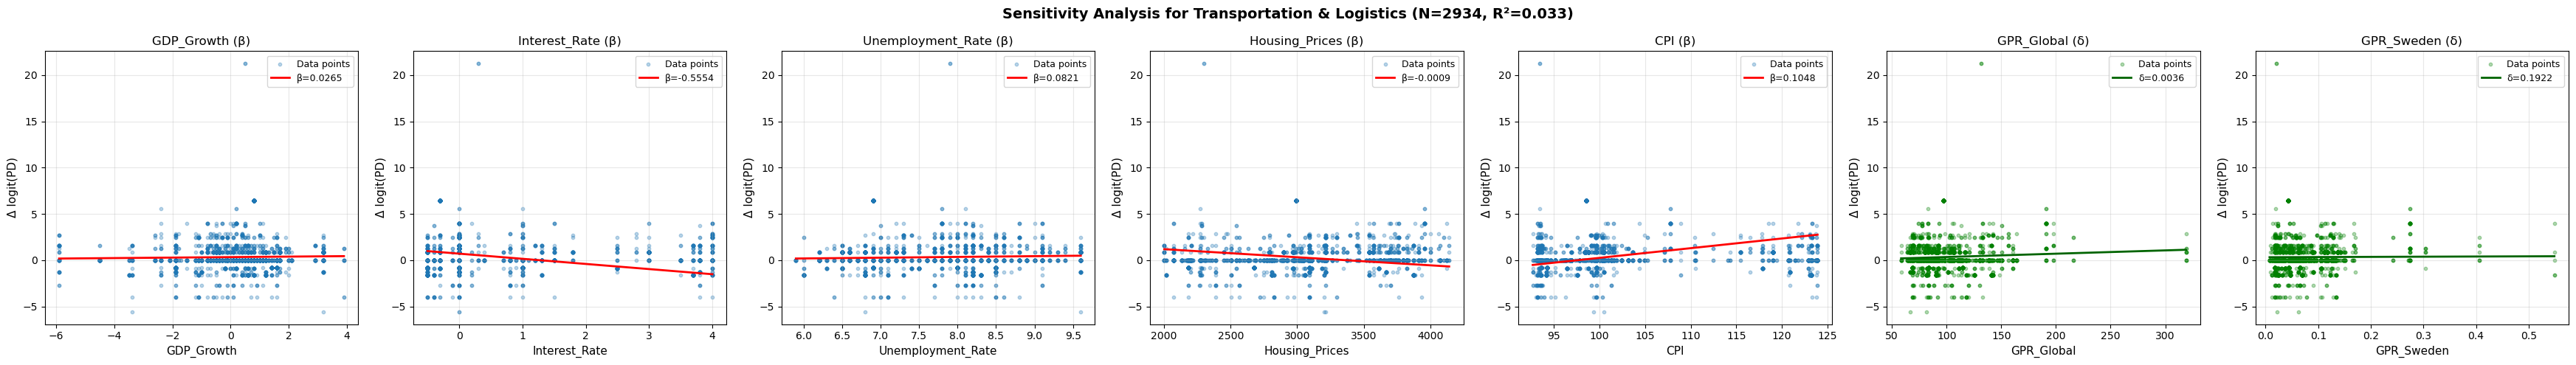


Completed plot for Transportation & Logistics


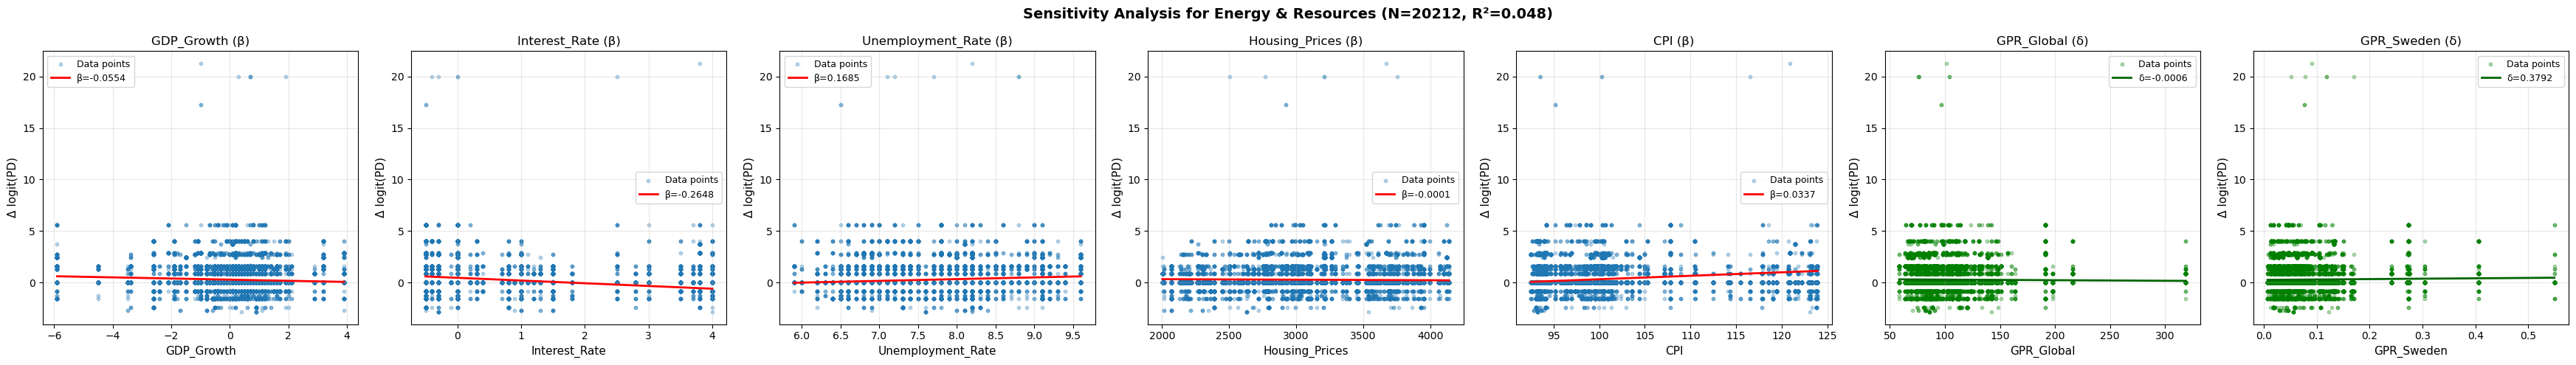


Completed plot for Energy & Resources


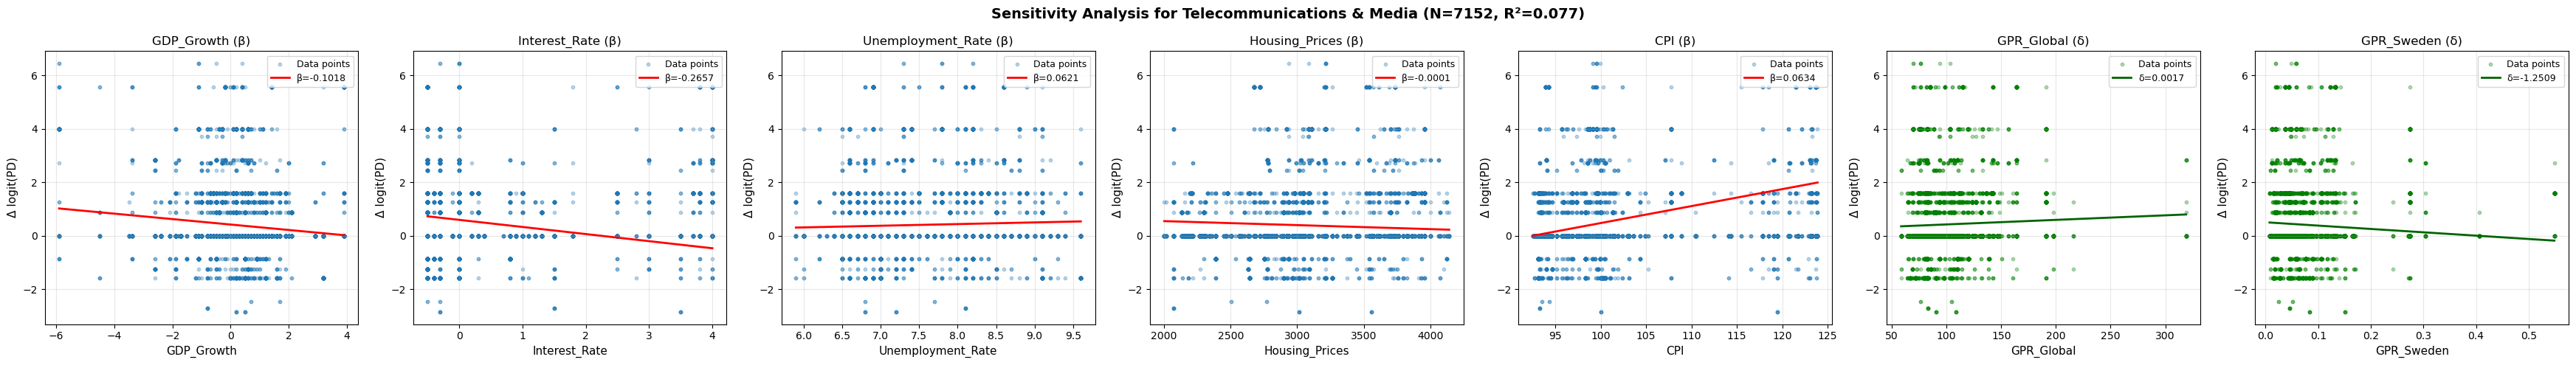


Completed plot for Telecommunications & Media


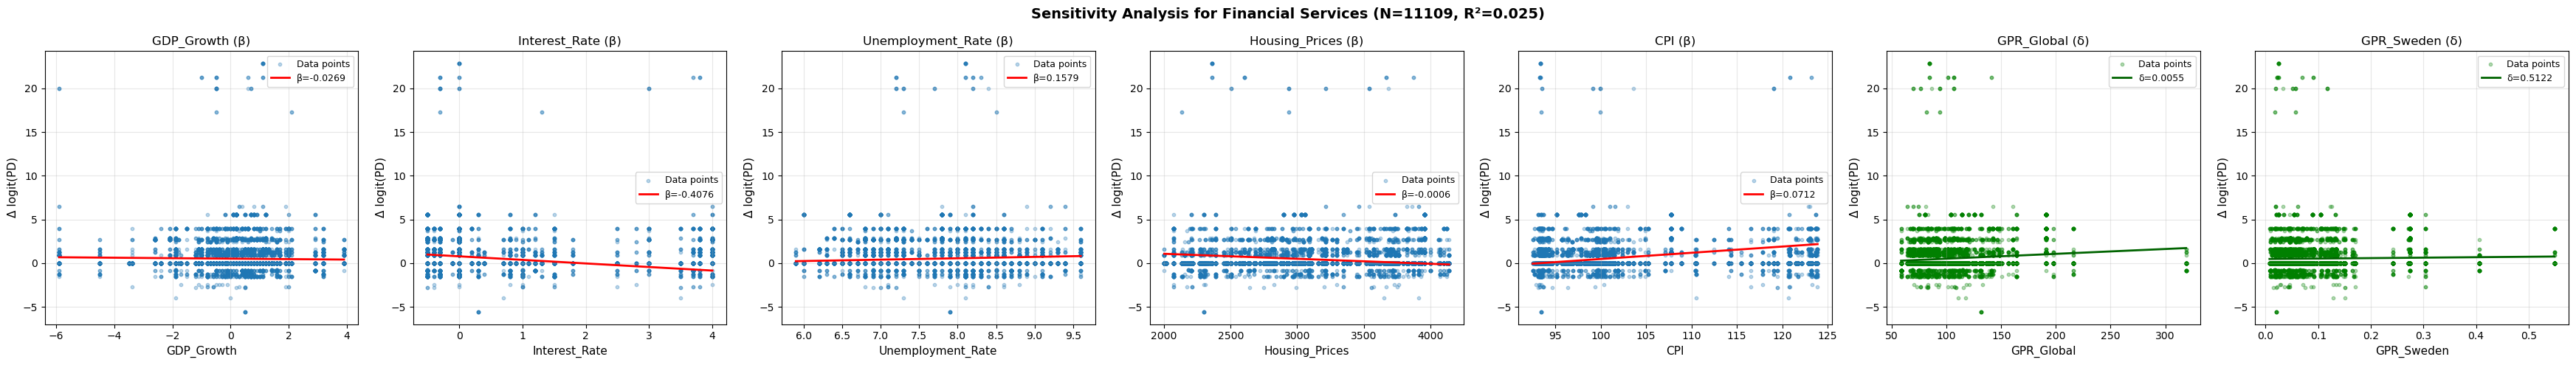


Completed plot for Financial Services


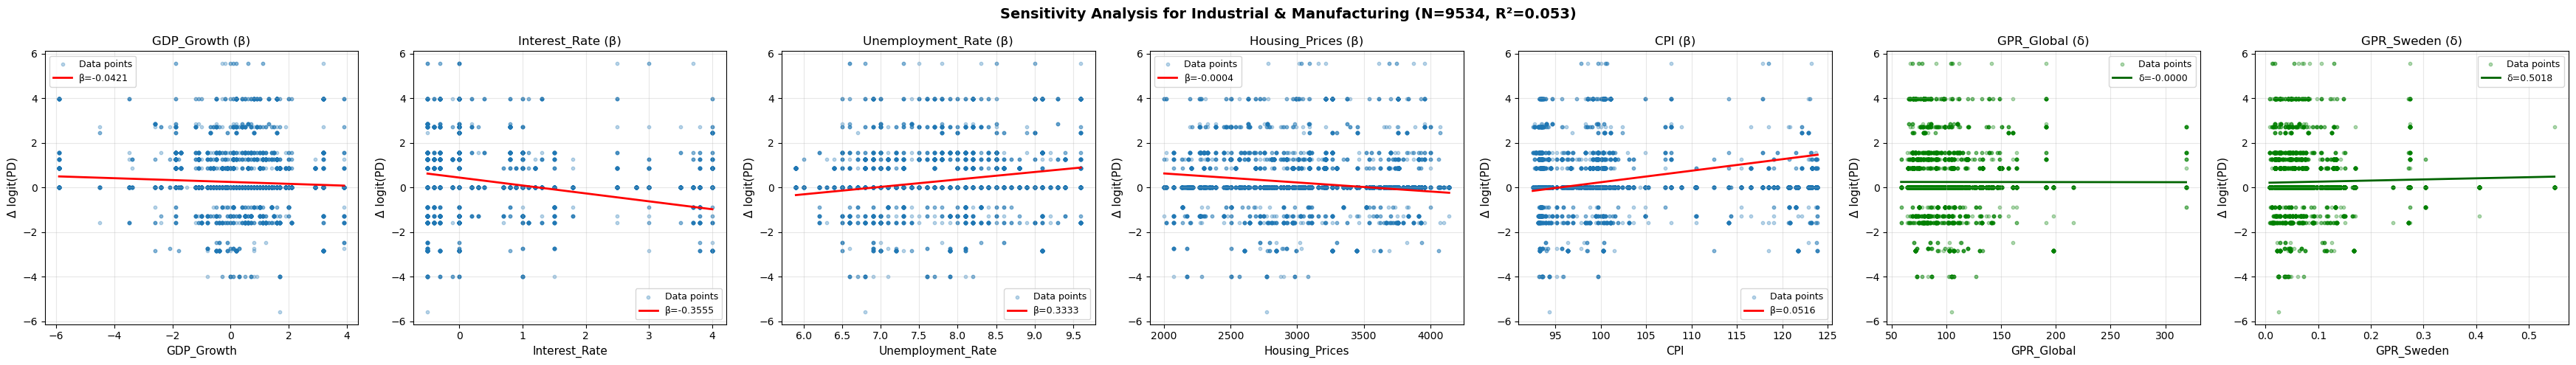


Completed plot for Industrial & Manufacturing


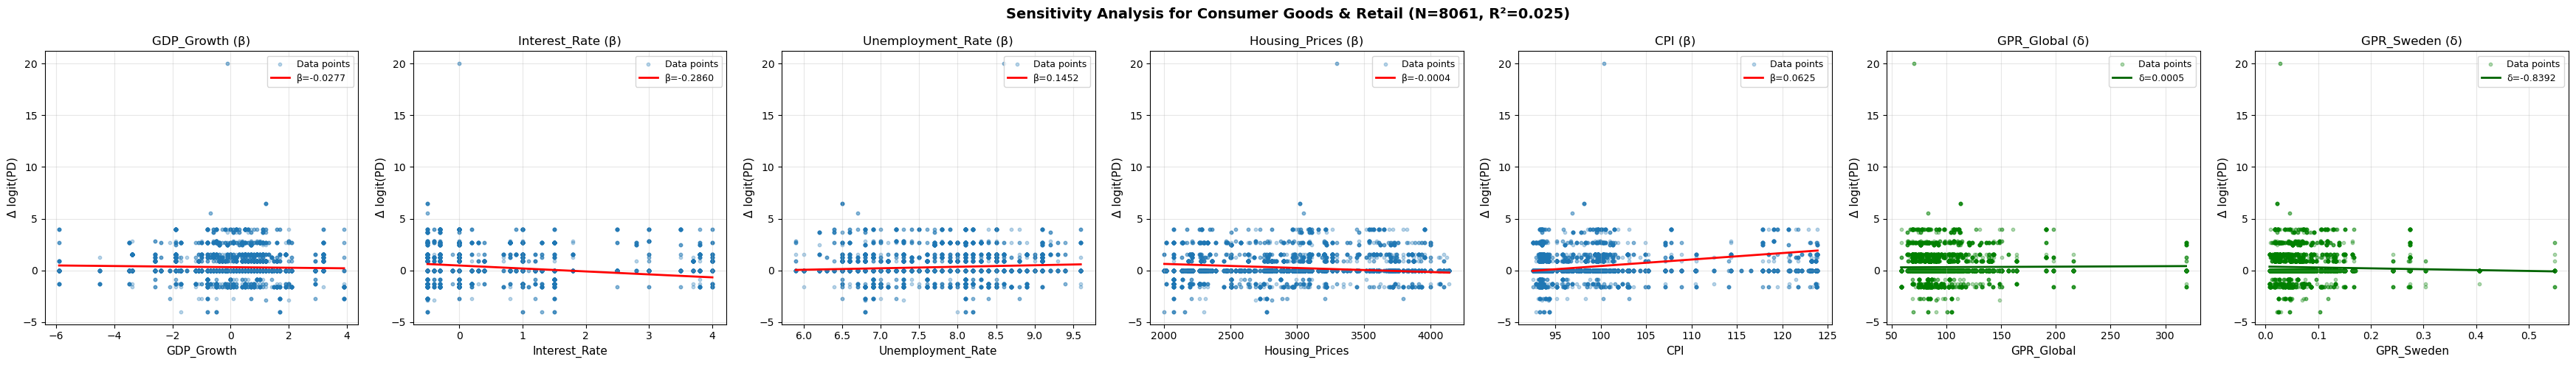


Completed plot for Consumer Goods & Retail


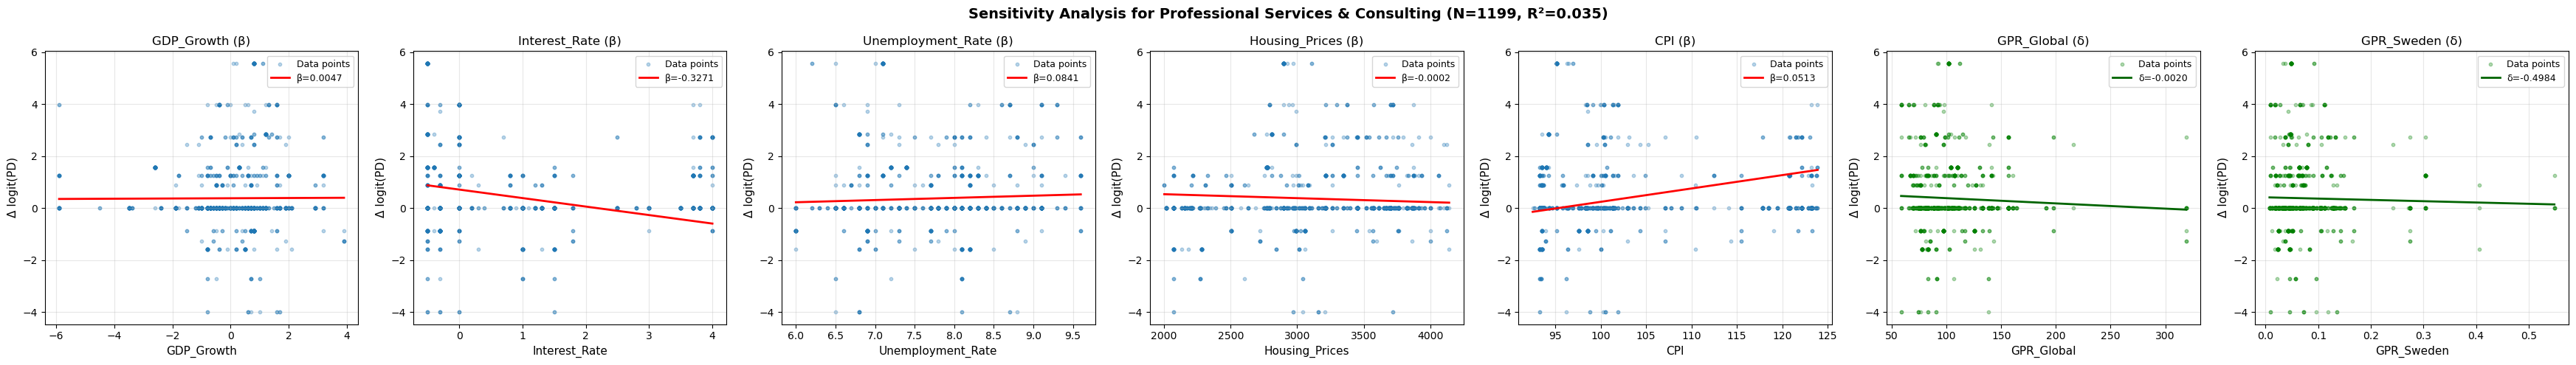


Completed plot for Professional Services & Consulting


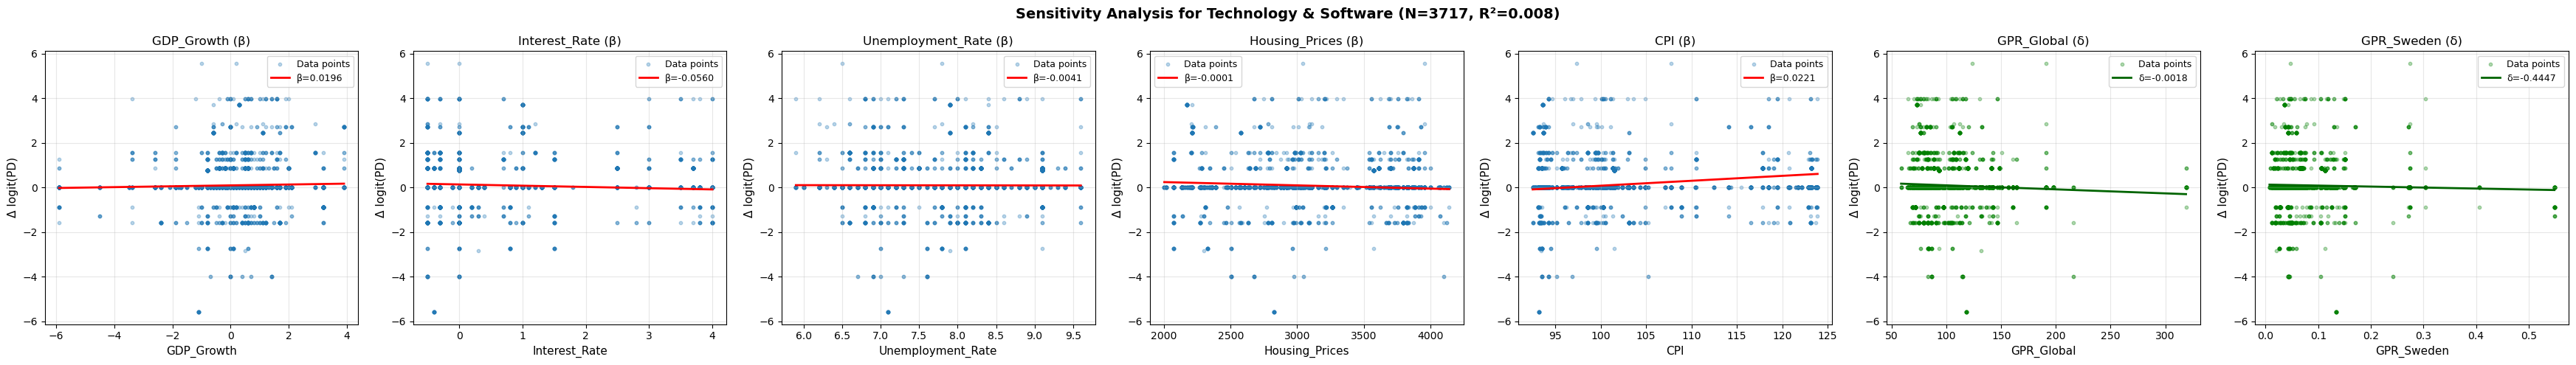


Completed plot for Technology & Software


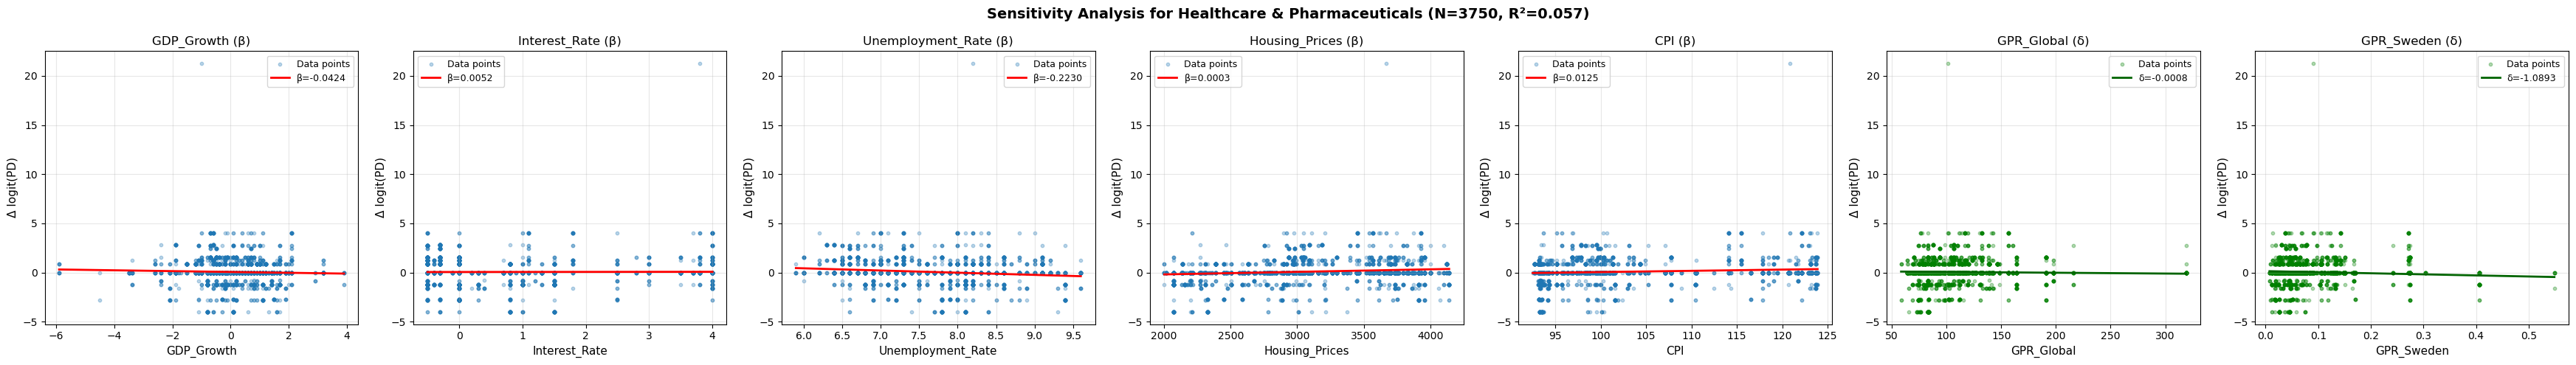


Completed plot for Healthcare & Pharmaceuticals


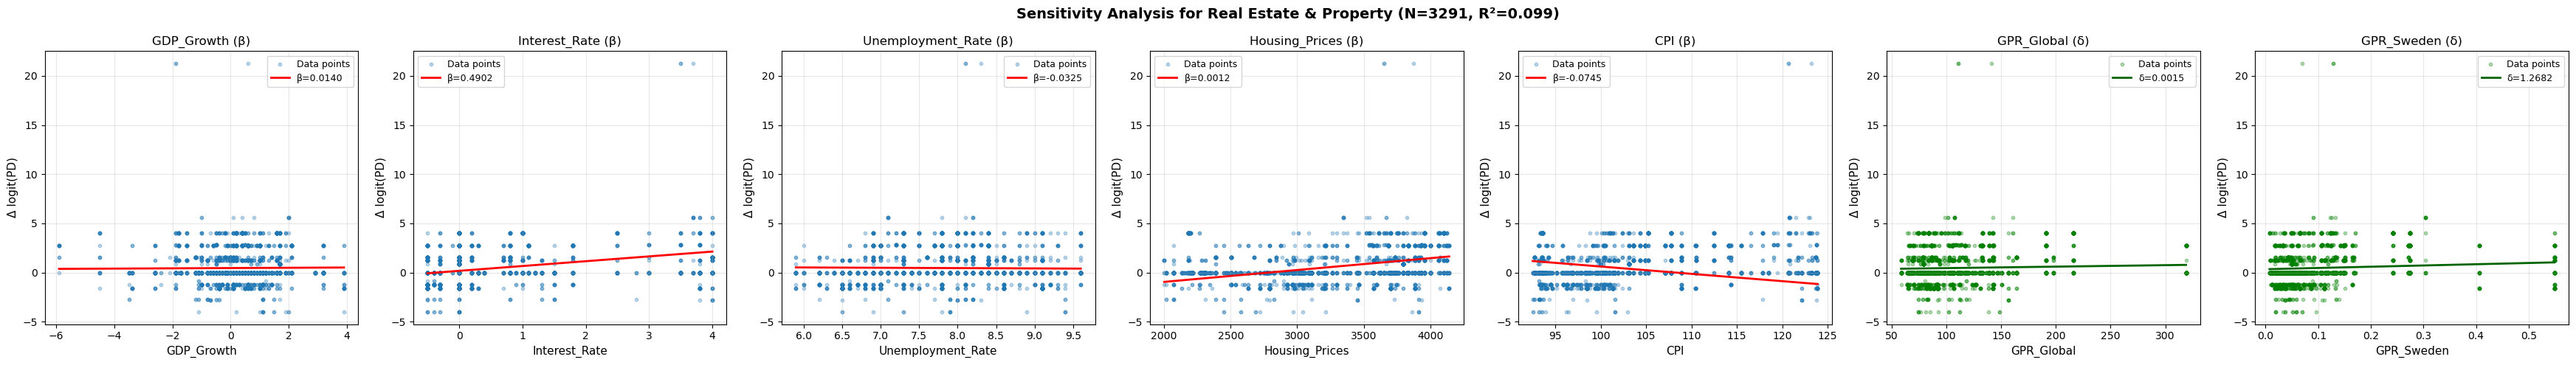


Completed plot for Real Estate & Property


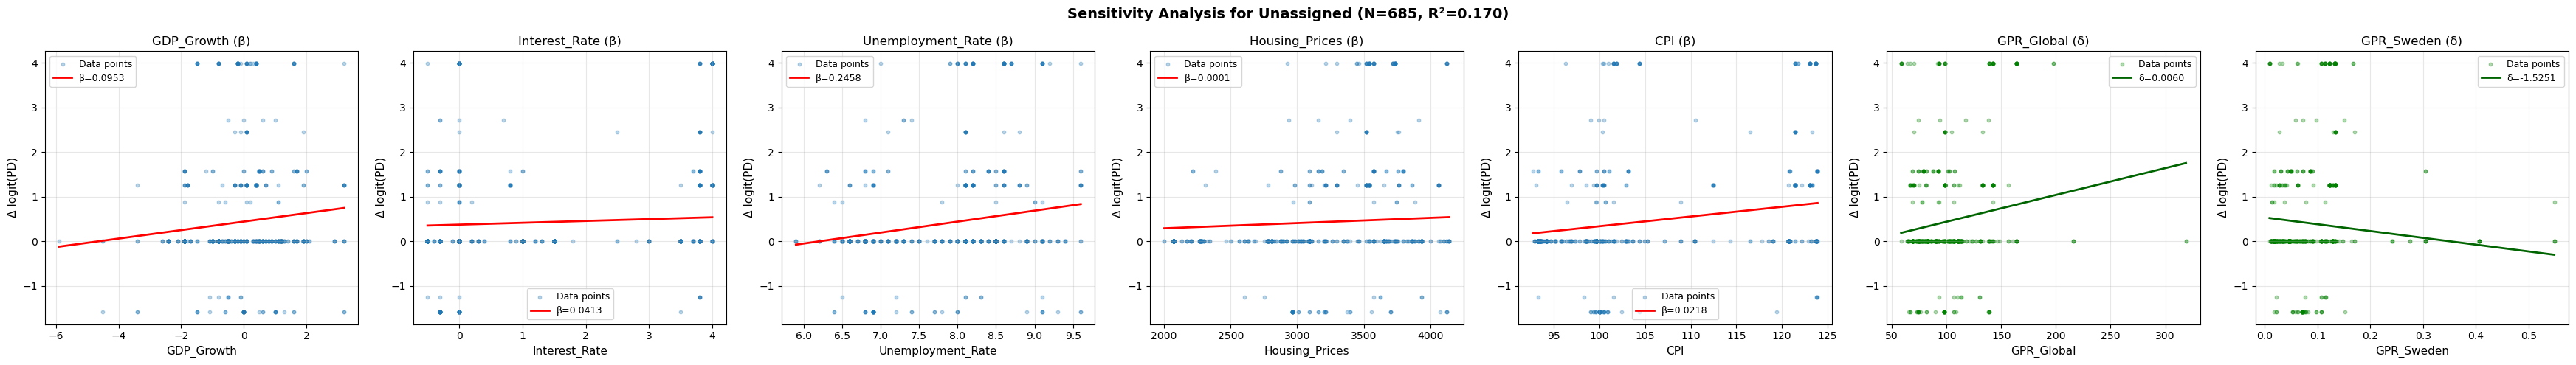


Completed plot for Unassigned


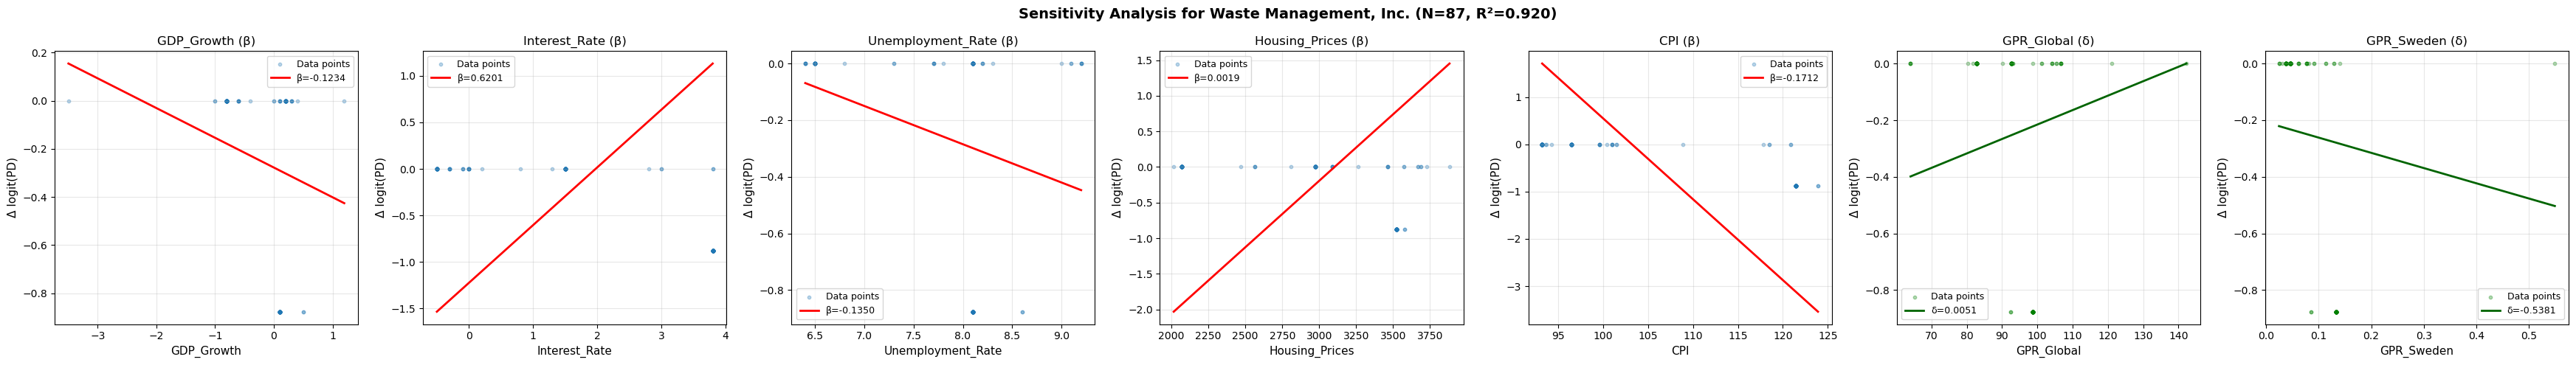


Completed plot for Waste Management, Inc.


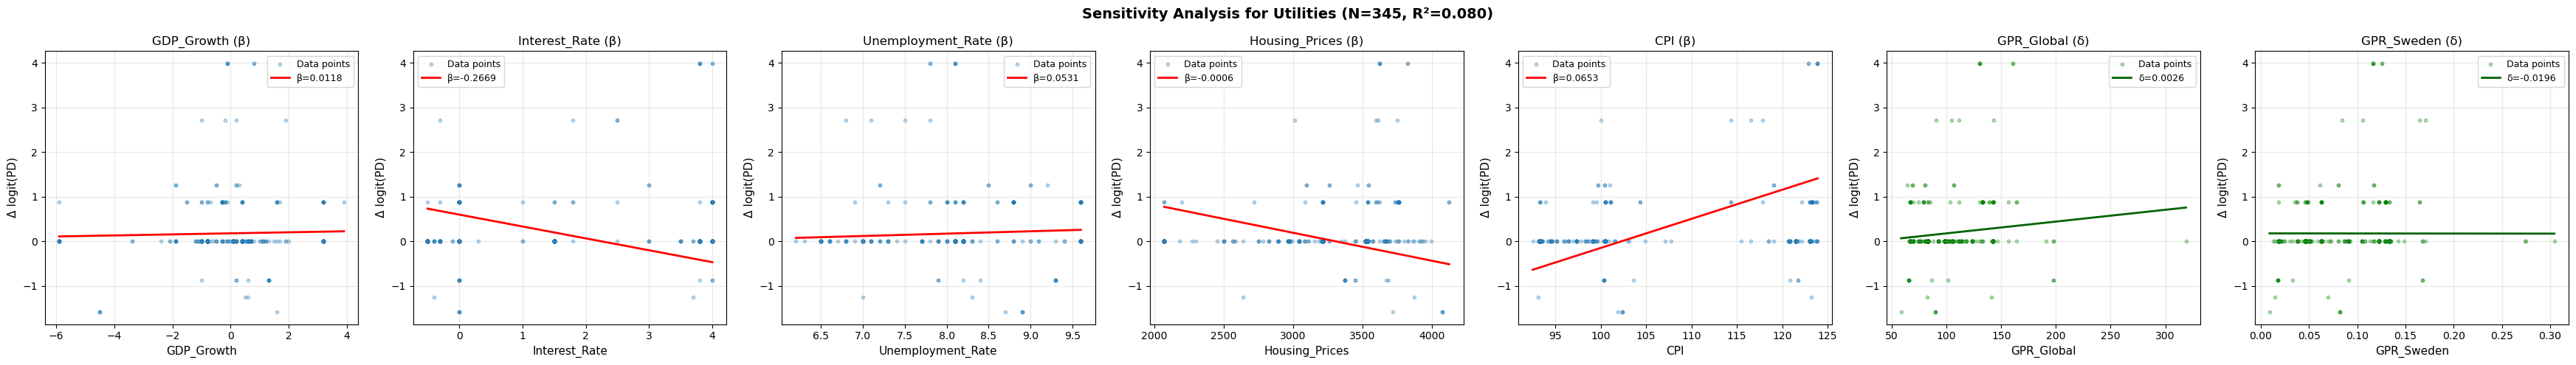


Completed plot for Utilities


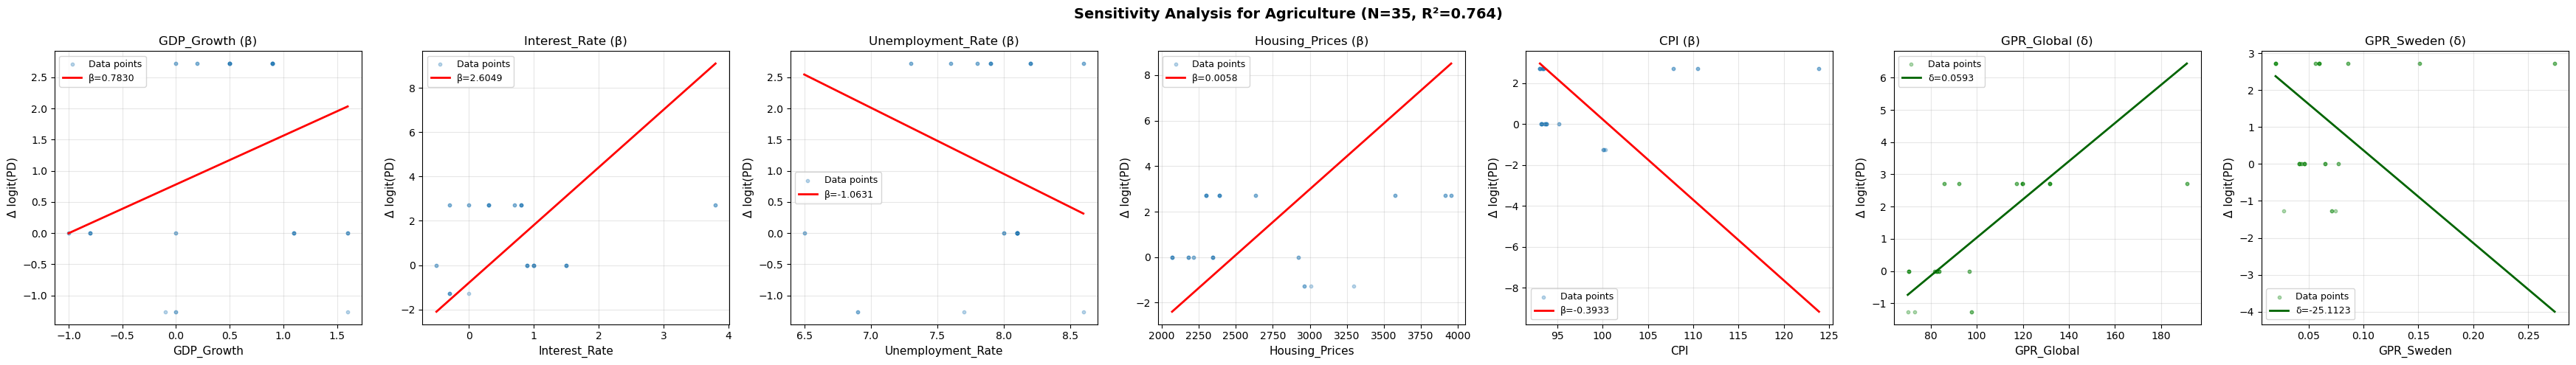


Completed plot for Agriculture


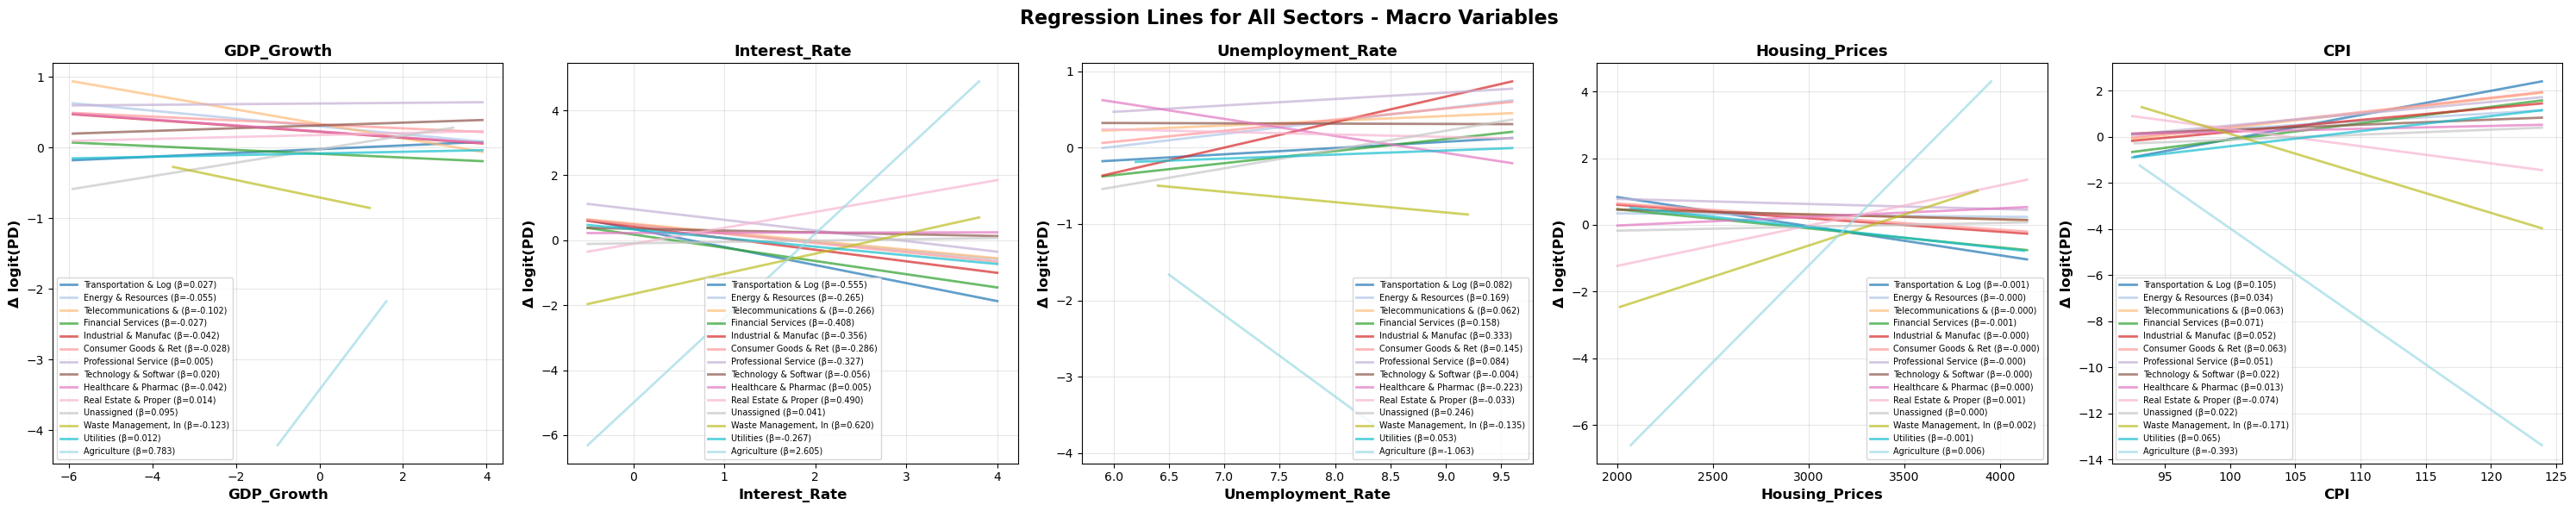


Completed comparison plot for all sectors


In [ ]:
# Sensitivity regression plots
plots.plot_sector_regressions(df_sensitivities, df_final_cleaned, config.MACRO_COLS, config.GPR_COLS, config.SECTOR_COL)

plots.plot_sector_comparison(
    df_sensitivities,
    df_final_cleaned,
    config.MACRO_COLS,
    sector_col=config.SECTOR_COL,
    title='Regression Lines for All Sectors - Macro Variables',
    ylabel='Δ logit(PD)',
)


In [ ]:
# Basel asset correlations (create/refresh correlation file)

df_exposures = pd.read_csv('data/PDs/pdsFitchData_latest_exposures.csv')
print(f"Loaded {len(df_exposures)} exposures from {df_exposures['Date'].iloc[0]}")
print(f"Unique companies: {df_exposures['Company_number'].nunique()}")
print(f"\nColumns: {df_exposures.columns.tolist()}")

print("\nExample: PD = 8.33% → ρ = {:.4f}".format(basel.asset_correlation_formula(0.0833)))

pd_columns = config.DEFAULT_PD_TENORS

df_exposures = basel.append_basel_correlations(df_exposures, pd_columns, verbose=True)

sample_cols = ['Company_number', 'Sector', '12_month', '12_month_correlation']
print("Sample results (12-month tenor):")
print("\n" + df_exposures[sample_cols].dropna(subset=['12_month']).head(15).to_string(index=False))

# Save for downstream steps
output_corr_path = 'data/PDs/pdsFitchData_latest_with_basel_correlation.csv'
df_exposures.to_csv(output_corr_path, index=False)
print(f"\n✓ Correlation-augmented exposures saved to: {output_corr_path}")


SyntaxError: unterminated f-string literal (detected at line 6) (226582034.py, line 6)

In [ ]:
# Scenario-based portfolio loss simulation
mean_vec = mean_vector[config.ALL_PREDICTOR_COLS].values
cov_mat = cov_matrix.loc[config.ALL_PREDICTOR_COLS, config.ALL_PREDICTOR_COLS].values

scenario_results = scenario.calculate_scenario_portfolio_loss(
    exposures_csv='data/PDs/pdsFitchData_latest_with_basel_correlation.csv',
    sensitivities_csv='sensitivity_results_with_CI.csv',
    macro_vars=config.MACRO_COLS,
    gpr_vars=config.GPR_COLS,
    n_scenarios=10000,
    tenor='12_month',
    ead=1_000_000,
    lgd=0.45,
    quantile=0.999,
    seed=42,
    mean_vec=mean_vec,
    cov_mat=cov_mat,
    verbose=True,
)


In [ ]:
# Scenario loss plots
plots.plot_scenario_loss(scenario_results)


In [ ]:
# Deterministic portfolio loss (single-quantile) + plots
portfolio_results = portfolio.calculate_portfolio_loss(
    exposures_csv='data/PDs/pdsFitchData_latest_with_basel_correlation.csv',
    tenor='12_month',
    ead=1_000_000,
    lgd=0.45,
    quantile=0.999,
    verbose=True,
)

plots.plot_portfolio_loss_breakdown(portfolio_results)


In [ ]:
# RWA calculations
print("=" * 70)
print("CALCULATING RWA FOR ENTIRE PORTFOLIO")
print("=" * 70)

# Load the data with Basel correlations
df_portfolio = pd.read_csv('data/PDs/pdsFitchData_latest_with_basel_correlation.csv')

print(f"\nDataset loaded: {len(df_portfolio)} exposures")
print(f"Columns: {list(df_portfolio.columns)}")

# Parameters
LGD = 0.45
EAD = 1_000_000
MATURITY = 2.5

print(f"\nPortfolio parameters:")
print(f"  LGD: {LGD:.2%}")
print(f"  EAD per exposure: {EAD:,.0f} SEK")
print(f"  Maturity: {MATURITY} years")
print(f"  Total Portfolio EAD: {EAD * len(df_portfolio):,.0f} SEK")

results_by_tenor = basel.compute_rwa_by_tenor(
    df_portfolio,
    tenors=config.DEFAULT_RWA_TENORS,
    lgd=LGD,
    ead=EAD,
    maturity=MATURITY,
)

basel.print_rwa_summary(results_by_tenor)
basel.print_rwa_detail_12m(results_by_tenor)


SyntaxError: unterminated f-string literal (detected at line 9) (1630124421.py, line 9)

In [ ]:
# CET1 ratio analysis
RWA_0 = 540_000_000
CET1_0 = RWA_0 * 0.18

cet1_results = capital.cet1_analysis(
    rwa_0=RWA_0,
    cet1_0=CET1_0,
    portfolio_loss=portfolio_results['total_loss'],
    results_by_tenor=results_by_tenor,
    tenor='12_month',
    verbose=True,
)
